# Multivariable Logistic Regression (ESBL)

This notebook explores predictors of ESBL status and checks model assumptions before fitting a multivariable logistic regression model.


## 1) Setup and Data Load


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy.builtins import Q 
import sklearn as sk
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split

analysis_df = pd.read_csv("synthetic_esbl_data.csv")

#remove n_sites and n_samples columns if they exist
analysis_df = analysis_df.loc[:, ~analysis_df.columns.isin(['n_sites', 'n_samples'])]

In [ ]:
analysis_df.columns

In [ ]:
'/Users/at5918/Downloads/RE_ iCARE export/multivariable_lr_esbl.ipynb'

In [ ]:
prophylaxis_mapping = {
    # Cephalosporin-based
    # "cefuroxime": "cephalosporin_based",
    # "cefuroxime | metronidazole": "cephalosporin_based",
    # "cefuroxime | gentamicin": "cephalosporin_based",
    # "cefuroxime | gentamicin | metronidazole": "cephalosporin_based",

    # Aminoglycoside-based (without cephalosporin)
    "gentamicin": "aminoglycoside_based",
    "gentamicin | metronidazole": "aminoglycoside_based",
    "gentamicin | teicoplanin": "aminoglycoside_based",

    # Glycopeptide
    "vancomycin": "glycopeptide_based",

    "cefuroxime | gentamicin": "cephalosporin_aminoglycoside",
    "cefuroxime | gentamicin | metronidazole": "cephalosporin_aminoglycoside",

    # # Anaerobic / narrow spectrum
    # "metronidazole": "anaerobic_only",
    # "clindamycin": "anaerobic_only",
}

analysis_df['prophylaxis_group'] = analysis_df['prophylaxis_group'].replace(prophylaxis_mapping)
analysis_df['prophylaxis_group'].value_counts()

prophylaxis_group
cefuroxime | metronidazole            605
co-amoxiclav (contains penicillin)    367
cefuroxime                            294
glycopeptide_based                    192
aminoglycoside_based                  175
clindamycin                           151
metronidazole                         132
no_prophylaxis                        129
cephalosporin_aminoglycoside           74
Name: count, dtype: int64

## Working Notes and TODO


- think of filling in missing data into a missing category - can hold information 
    -  df['antibiotic'] = df['antibiotic'].fillna('Missing')

- collinearity and multicollinearity (variables highly correalted) is bad bc model can't tell which variable is responsible for the changes in outcome 
    - coefficients become unstable + very larger CIs

- dummy variables - binary encodings of categorical variables
    - drop one category so you don't get a perfect linear relationship = one variable cannot be exactly predicted from others 

- what is EPV? (number of events/ number of variables)
     - needs to be >10


**Final intuitions**:

- Dummy variables → allow categories into regression
- Dropping one → avoids mathematical impossibility
- VIF → detects redundancy
- EPV → protects against overfitting
- AUROC → evaluates prediction, not causality

## 2) Feature Engineering and EPV Check

Create dummy variables for categorical predictors and calculate events-per-variable (EPV) to gauge model stability.


In [ ]:
# Get dummy variables

reference_categories = {
    'species': 'escherichia coli',
    'specimen_site': 'blood',
    'ethnicity': 'white',
    'prophylaxis': 'cefuroxime | metronidazole',
    'specialty': 'general_surgery'
}

categorical_cols = analysis_df.select_dtypes(include=["object", "category"]).columns

multi_lr_df = pd.get_dummies(
    analysis_df,
    columns=categorical_cols,
    prefix=categorical_cols,
    prefix_sep="__"
)

for column_name, reference_category in reference_categories.items():
    reference_column = f"{column_name}__{reference_category}"
    multi_lr_df = multi_lr_df.drop(columns=reference_column, errors="ignore")

# Compute EPV = events per variable = number of positive events / number of predictors (including dummies)
predictor_cols = [col for col in multi_lr_df.columns if col != "esbl_status"]
epv = multi_lr_df["esbl_status"].sum() / len(predictor_cols)
print(f"Events per variable (EPV): {epv:.2f}")

Events per variable (EPV): 10.33


/var/folders/ng/nhpn14f13zd0rx8vyc9ykj1h0000gp/T/ipykernel_17286/2675686665.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = analysis_df.select_dtypes(include=["object", "category"]).columns


In [ ]:
# # handle missing variables 

# col_has_missing = multi_lr_df.columns[multi_lr_df.isna().any()].tolist()
# print("Columns with missing values:", col_has_missing)

# multi_lr_df['imd_decile'] = multi_lr_df['imd_decile'].fillna(multi_lr_df['imd_decile'].median()) 

## 3) VIF and Correlation Screen for Multicollinearity

Visualize the correlation matrix to identify highly correlated predictors before model fitting.

- use Pearson's corrrelation coefficient to screen for collinearity
- VIF - variance inflation factor 


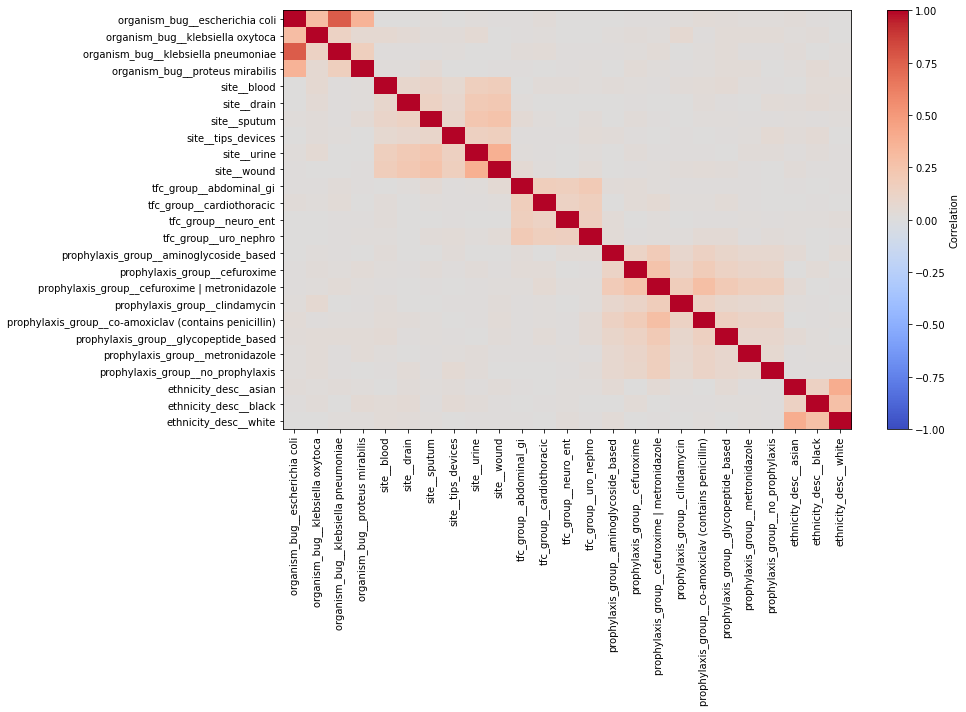

In [ ]:
# Define a threshold for the absolute value of correlation
threshold = 0.15

# Select predictors only (exclude outcome) using column-safe indexing
predictor_df = multi_lr_df.drop(columns=['esbl_status'], errors='ignore')

# Correlation among predictors
corr_matrix = predictor_df.corr().abs()

# Keep variables that have at least one correlation above threshold (excluding self-correlation)
relevant_vars = corr_matrix.columns[(corr_matrix > threshold).sum() > 1]

# Apply the threshold to the correlation matrix
filtered_corr = corr_matrix.loc[relevant_vars, relevant_vars]

plt.figure(figsize=(14, 10))
plt.imshow(filtered_corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(filtered_corr.columns)), filtered_corr.columns, rotation=90)
plt.yticks(range(len(filtered_corr.index)), filtered_corr.index)
plt.tight_layout()
plt.show()

In [ ]:

# Example predictor matrix
X = multi_lr_df.copy()
X = X.drop(columns=['esbl_status'])

# Convert boolean columns to integers
bool_cols = X.dtypes[X.dtypes == 'bool'].index
X[bool_cols] = X[bool_cols].astype(int)

# Drop rows with NaN values
X = X.dropna()

# Add constant
X = sm.add_constant(X)

vif_df = pd.DataFrame()
vif_df['variable'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_df = vif_df.sort_values(by="VIF", ascending=False)

print(vif_df[vif_df['VIF'] > 5])

/Users/at5918/miniconda3/envs/iCARE_env/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/at5918/miniconda3/envs/iCARE_env/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                             variable        VIF
16                   organism_bug__klebsiella oxytoca        inf
18                    organism_bug__proteus mirabilis        inf
17                organism_bug__klebsiella pneumoniae        inf
15                     organism_bug__escherichia coli        inf
27                                        site__wound  28.839952
26                                        site__urine  26.804465
40      prophylaxis_group__cefuroxime | metronidazole  25.491234
43  prophylaxis_group__co-amoxiclav (contains peni...  17.902535
23                                       site__sputum  16.108703
39                      prophylaxis_group__cefuroxime  15.626104
20                                        site__drain  13.155997
28                            tfc_group__abdominal_gi  10.831134
44              prophylaxis_group__glycopeptide_based  10.695625
36                              tfc_group__uro_nephro  10.131829
38            prophylaxis

## 5) Modeling and Diagnostics 

Fit the logistic regression model here and report: odds ratios, confidence intervals, goodness-of-fit, and discrimination metrics.


In [ ]:
df_model = multi_lr_df.copy()
df_model.columns = df_model.columns.str.replace(" ", "_")
df_model = df_model.dropna()


X = df_model.drop(columns=["esbl_status"])
y = df_model["esbl_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [ ]:

formula = "esbl_status ~ " + " + ".join([f'Q("{col}")' for col in df_model.columns if col != "esbl_status"])

model = smf.logit(
    formula,
    data=X_train.assign(esbl_status=y_train)
).fit(disp=False)

print(model.summary())

                           Logit Regression Results                           
Dep. Variable:            esbl_status   No. Observations:                 1402
Model:                          Logit   Df Residuals:                     1353
Method:                           MLE   Df Model:                           48
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                 0.03827
Time:                        13:58:01   Log-Likelihood:                -744.73
converged:                       True   LL-Null:                       -774.36
Covariance Type:            nonrobust   LLR p-value:                    0.1276
                                                                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                             -1.2810   3.24e+06  -3.96e-0

In [ ]:
y_pred = model.predict(X_test)

auc = roc_auc_score(y_test, y_pred)
print(auc)

0.517422470384064


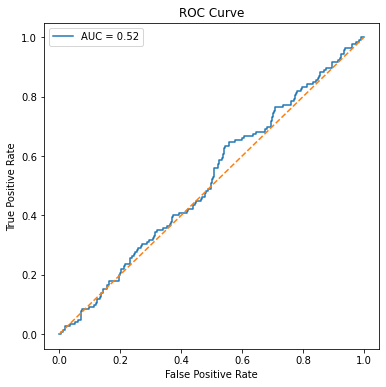

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
params = model.params
conf = model.conf_int()

or_df = pd.DataFrame({
    "OR": np.exp(params),
    "CI_lower": np.exp(conf[0]),
    "CI_upper": np.exp(conf[1]),
    "p_value": model.pvalues
})

# Drop intercept (not useful for plotting)
or_df = or_df.drop("Intercept")

# Optional: clean variable names
or_df.index.name = "variable"
or_df = or_df.reset_index()

/Users/at5918/miniconda3/envs/iCARE_env/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


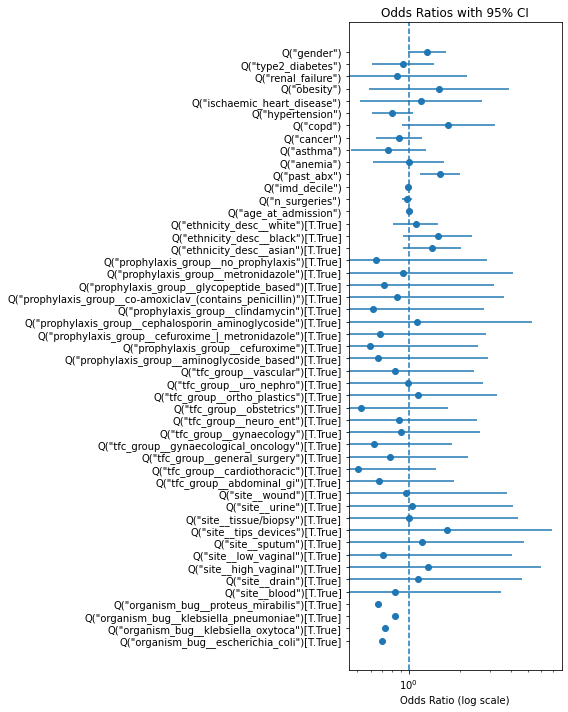

In [ ]:
plt.figure(figsize=(8, 10))

plt.errorbar(
    x=or_df["OR"],
    y=or_df["variable"],
    xerr=[
        or_df["OR"] - or_df["CI_lower"],
        or_df["CI_upper"] - or_df["OR"]
    ],
    fmt='o'
)

plt.axvline(x=1, linestyle='--')  # OR = 1 line

plt.xlabel("Odds Ratio (log scale)")
plt.xscale("log")
plt.ylabel("")
plt.title("Odds Ratios with 95% CI")

plt.tight_layout()
plt.show()

In [ ]:
or_df.rename(columns={'variable':'term'})

,term,OR,CI_lower,CI_upper,p_value
0,"Q(""organism_bug__escherichia_coli"")[T.True]",0.699216,0.000000,inf,1.000000
1,"Q(""organism_bug__klebsiella_oxytoca"")[T.True]",0.727589,0.000000,inf,1.000000
2,"Q(""organism_bug__klebsiella_pneumoniae"")[T.True]",0.826357,0.000000,inf,1.000000
3,"Q(""organism_bug__proteus_mirabilis"")[T.True]",0.660726,0.000000,inf,1.000000
4,"Q(""site__blood"")[T.True]",0.831009,0.197659,3.493777,0.800545
5,"Q(""site__drain"")[T.True]",1.132239,0.278812,4.597950,0.862103
6,"Q(""site__high_vaginal"")[T.True]",1.298233,0.282450,5.967103,0.737330
7,"Q(""site__low_vaginal"")[T.True]",0.705511,0.124032,4.013054,0.694101
8,"Q(""site__sputum"")[T.True]",1.189003,0.297142,4.757756,0.806697
9,"Q(""site__tips_devices"")[T.True]",1.667216,0.401835,6.917298,0.481369


In [ ]:
import re
import pandas as pd

def split_term(term):
    if term == "Intercept":
        return "Intercept", ""
    
    # Match dummy-coded terms like Q("site__urine")[T.True]
    match = re.match(r'Q\("(.+?)"\)\[T\.True\]', term)
    if match:
        full_name = match.group(1)   # e.g. organism_bug__klebsiella_oxytoca
        
        if "__" in full_name:
            predictor, category = full_name.split("__", 1)
        else:
            predictor, category = full_name, ""
        
        return predictor, category
    
    # Continuous / binary terms like Q("age_at_admission")
    match2 = re.match(r'Q\("(.+?)"\)', term)
    if match2:
        return match2.group(1), ""
    
    return term, ""

term_col = "term" if "term" in or_df.columns else "variable"

or_df[["predictor", "category"]] = or_df[term_col].apply(
    lambda x: pd.Series(split_term(x))
)

rename_dict = {
    "organism_bug": "Organism",
    "site": "Sample site",
    "tfc_group": "Surgery type",
    "prophylaxis_group": "Prophylaxis",
    "ethnicity_desc": "Ethnicity",
    "age_at_admission": "Age",
    "imd_decile": "Deprivation",
    "past_abx": "Prior antibiotics"
}

or_df["predictor"] = or_df["predictor"].replace(rename_dict)

In [ ]:
plot_df = or_df.copy()

plot_df = plot_df[
    np.isfinite(plot_df["OR"]) &
    np.isfinite(plot_df["CI_lower"]) &
    np.isfinite(plot_df["CI_upper"]) &
    (plot_df["CI_lower"] > 0) &
    (plot_df["CI_upper"] < 20)
].copy()


# -----------------------------
# 2. Keep only predictors
# -----------------------------
predictor_map = {
    "organism_bug": "Organism",
    "site": "Infection site",
    "prophylaxis_group": "Prophylaxis",
    "tfc_group": "Surgical specialty",
}

plot_df = plot_df[plot_df["predictor"].isin(predictor_map.keys())].copy()
plot_df["group"] = plot_df["predictor"].map(predictor_map)

print(plot_df["group"])

# -----------------------------
# 3. Clean labels
# -----------------------------
category_map = {

    # organisms
    "escherichia coli": "E. coli",
    "klebsiella pneumoniae": "K. pneumoniae",
    "klebsiella oxytoca": "K. oxytoca",
    "proteus mirabilis": "P. mirabilis",

    # sites
    "blood": "Blood",
    "drain": "Drain",
    "respiratory pleural": "Resp./pleural",
    "wound": "Wound",
    "catheter_tips_devices": "Catheter/device",
    "tissue biopsy": "Tissue/biopsy",
    "other_unknown": "Other/unknown",
    "sputum": "Sputum",
    "genital": "Genital",
    "urine": "Urine",

    # surgical specialties
    "cardiology cardiothoracic surgery": "Cardiothoracic",
    "hepatobiliary & pancreatic surgery": "HPB surgery",
    "trauma & orthopaedics": "T&O",
    "gynaecological oncology": "Gynae oncology",
    "plastic surgery": "Plastic",
    "general surgery": "General surgery",
    "colorectal surgery": "Colorectal",
    "vascular surgery": "Vascular",
    "neurosurgery": "Neurosurgery",
    "obstetrics": "Obstetrics",
    "urology": "Urology",
    "gynaecology": "Gynaecology",
    "ent": "ENT",
    "other": "Other",
    "nephrology": "Nephrology",

    # prophylaxis
    "broad_spectrum_other": "Broad-spectrum other",
    "no_recorded_prophylaxis": "No prophylaxis recorded",
    "co-amoxiclav": "Co-amoxiclav",
    "glycopeptide": "Glycopeptide",
    "clindamycin": "Clindamycin",
    "gentamicin": "Gentamicin",
    "cefuroxime": "Cefuroxime",
}

plot_df["label"] = plot_df["category"].replace(category_map)

plot_df

Series([], Name: group, dtype: str)


,variable,OR,CI_lower,CI_upper,p_value,predictor,category,group,label


Series([], Name: group, dtype: str)


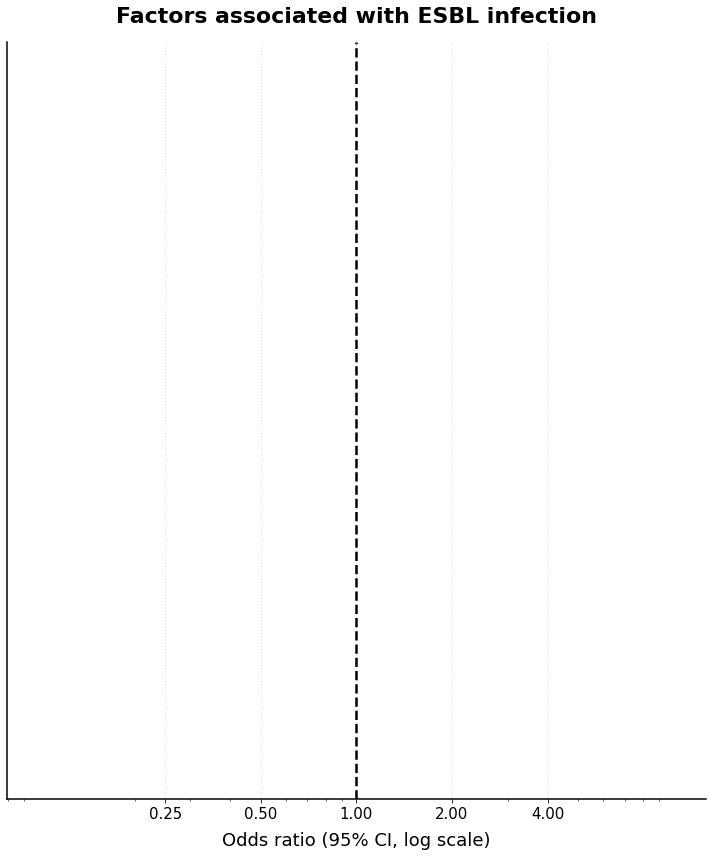

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# -----------------------------
# 1. Copy results
# -----------------------------
plot_df = or_df.copy()

plot_df = plot_df[
    np.isfinite(plot_df["OR"]) &
    np.isfinite(plot_df["CI_lower"]) &
    np.isfinite(plot_df["CI_upper"]) &
    (plot_df["CI_lower"] > 0) &
    (plot_df["CI_upper"] < 20)
].copy()

# -----------------------------
# 2. Keep only predictors
# -----------------------------
predictor_map = {
    "organism_bug": "Organism",
    "site": "Infection site",
    "prophylaxis_group": "Prophylaxis",
    "tfc_group": "Surgical specialty",
}

plot_df = plot_df[plot_df["predictor"].isin(predictor_map.keys())].copy()
plot_df["group"] = plot_df["predictor"].map(predictor_map)

print(plot_df["group"])

# -----------------------------
# 3. Clean labels
# -----------------------------
category_map = {

    # organisms
    "escherichia coli": "E. coli",
    "klebsiella pneumoniae": "K. pneumoniae",
    "klebsiella oxytoca": "K. oxytoca",
    "proteus mirabilis": "P. mirabilis",

    # sites
    "blood": "Blood",
    "drain": "Drain",
    "respiratory pleural": "Resp./pleural",
    "wound": "Wound",
    "catheter_tips_devices": "Catheter/device",
    "tissue biopsy": "Tissue/biopsy",
    "other_unknown": "Other/unknown",
    "sputum": "Sputum",
    "genital": "Genital",
    "urine": "Urine",

    # surgical specialties
    "cardiology cardiothoracic surgery": "Cardiothoracic",
    "hepatobiliary & pancreatic surgery": "HPB surgery",
    "trauma & orthopaedics": "T&O",
    "gynaecological oncology": "Gynae oncology",
    "plastic surgery": "Plastic",
    "general surgery": "General surgery",
    "colorectal surgery": "Colorectal",
    "vascular surgery": "Vascular",
    "neurosurgery": "Neurosurgery",
    "obstetrics": "Obstetrics",
    "urology": "Urology",
    "gynaecology": "Gynaecology",
    "ent": "ENT",
    "other": "Other",
    "nephrology": "Nephrology",

    # prophylaxis
    "broad_spectrum_other": "Broad-spectrum other",
    "no_recorded_prophylaxis": "No prophylaxis recorded",
    "co-amoxiclav": "Co-amoxiclav",
    "glycopeptide": "Glycopeptide",
    "clindamycin": "Clindamycin",
    "gentamicin": "Gentamicin",
    "cefuroxime": "Cefuroxime",
}

plot_df["label"] = plot_df["category"].replace(category_map)

# -----------------------------
# 4. Sort groups
# -----------------------------
group_order = ["Organism", "Infection site", "Prophylaxis", "Surgical specialty"]

plot_df["group"] = pd.Categorical(
    plot_df["group"],
    categories=group_order,
    ordered=True
)

plot_df = plot_df.sort_values(
    ["group", "OR"],
    ascending=[True, False]
).reset_index(drop=True)

# -----------------------------
# 5. Create y positions with gaps
# -----------------------------
y_positions = []
current_y = 0

for grp in group_order:
    df_grp = plot_df[plot_df["group"] == grp]
    
    for _ in range(len(df_grp)):
        y_positions.append(current_y)
        current_y += 1
    
    current_y += 1  # gap between groups

plot_df["y"] = y_positions
plot_df["significant"] = plot_df["p_value"] < 0.05

# -----------------------------
# 6. Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, max(12, 0.45 * len(plot_df))))

# --- non-significant
df_nonsig = plot_df[~plot_df["significant"]]

ax.errorbar(
    df_nonsig["OR"],
    df_nonsig["y"],
    xerr=[
        df_nonsig["OR"] - df_nonsig["CI_lower"],
        df_nonsig["CI_upper"] - df_nonsig["OR"]
    ],
    fmt='o',
    color="0.65",
    ecolor="0.65",
    elinewidth=2,
    capsize=3,
    capthick=1,
    markersize=8,
    alpha=0.9
)

# --- significant
df_sig = plot_df[plot_df["significant"]]

ax.errorbar(
    df_sig["OR"],
    df_sig["y"],
    xerr=[
        df_sig["OR"] - df_sig["CI_lower"],
        df_sig["CI_upper"] - df_sig["OR"]
    ],
    fmt='o',
    color="navy",
    ecolor="navy",
    elinewidth=2,
    capsize=3,
    capthick=1,
    markersize=8
)

# --- annotate OR values
for _, row in df_sig.iterrows():
    ax.text(
        row["OR"],
        row["y"] - 0.25,
        f"{row['OR']:.2f}",
        ha="center",
        va="bottom",
        fontsize=12,
        color="navy"
    )

# -----------------------------
# 7. Styling
# -----------------------------
ax.axvline(1, color="black", linestyle="--", linewidth=2.5)

ax.set_yticks(plot_df["y"])
ax.set_yticklabels(plot_df["label"], fontsize=16)

ax.set_xscale("log")
ax.set_xticks([0.25, 0.5, 1, 2, 4])
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())

ax.tick_params(axis="x", labelsize=15)

ax.set_xlabel(
    "Odds ratio (95% CI, log scale)",
    fontsize=18,
    labelpad=10
)

ax.set_title(
    "Factors associated with ESBL infection",
    fontsize=22,
    weight="bold",
    pad=20
)

ax.grid(axis="x", linestyle=":", alpha=0.35, linewidth=1.2)
ax.grid(axis="y", visible=False)

ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.invert_yaxis()

plt.tight_layout()
plt.savefig("figure_poster.png")
plt.show()